# Dynamic Routing Between Capsules — Summary

# https://www.cs.toronto.edu/~hinton/absps/DynamicRouting.pdf

## Abstract
This paper introduces capsules, groups of neurons whose vector output encodes both the probability that an entity exists (via vector length) and its instantiation parameters (via vector orientation). Active lower-level capsules make predictions for higher-level capsule outputs via learned transformation matrices, and an iterative "routing-by-agreement" mechanism determines how strongly each lower-level capsule contributes to each higher-level capsule. The resulting CapsNet architecture achieves state-of-the-art performance on MNIST and substantially outperforms convolutional networks at recognizing highly overlapping digits (MultiMNIST), while also demonstrating improved robustness to affine transformations.

## Problems
- Convolutional neural networks (CNNs) rely on max-pooling, a crude routing mechanism that discards precise spatial and pose information by retaining only the most active feature in a local pool.
- CNNs generalize poorly to novel viewpoints; handling affine transformations beyond translation requires either exponentially many replicated feature detectors or exponentially larger labeled datasets.
- Standard neural representations struggle with the "binding problem" — correctly assigning parts to wholes — and with segmenting/recognizing multiple highly overlapping objects in an image.
- One-of-n or scalar-activation representations (as in older models like HMMs) are exponentially inefficient at representing structured, multi-dimensional entity properties compared to distributed vector representations.

## Proposed Solutions
- Represent visual entities using capsules: vectors whose length (bounded in $$[0,1]$$) encodes existence probability and whose orientation encodes instantiation parameters (pose, deformation, texture, etc.).
- Apply a non-linear "squashing" function to capsule outputs:
$$v_j = \frac{\|s_j\|^2}{1+\|s_j\|^2}\frac{s_j}{\|s_j\|}$$
- Compute higher-level capsule inputs as a weighted sum of prediction vectors from lower-level capsules:
$$s_j = \sum_i c_{ij}\hat{u}_{j|i}, \quad \hat{u}_{j|i} = W_{ij}u_i$$
- Determine coupling coefficients $$c_{ij}$$ via a routing softmax over log-prior logits $$b_{ij}$$:
$$c_{ij} = \frac{\exp(b_{ij})}{\sum_k \exp(b_{ik})}$$
- Iteratively refine routing by adding the scalar-product agreement $$a_{ij} = v_j \cdot \hat{u}_{j|i}$$ to $$b_{ij}$$ over several iterations (routing-by-agreement), strengthening coupling between capsules whose predictions agree.
- Train the top-level DigitCaps capsules with a per-class margin loss:
$$L_k = T_k \max(0, m^+ - \|v_k\|)^2 + \lambda(1-T_k)\max(0, \|v_k\|-m^-)^2$$
- Add an auxiliary reconstruction loss (via a 3-layer fully connected decoder) as a regularizer that encourages digit capsules to encode complete instantiation parameters.

## Purpose
The paper aims to demonstrate that vector-output capsules combined with a dynamic, agreement-based routing mechanism can overcome key representational limitations of CNNs — particularly for viewpoint generalization and segmentation of overlapping objects — while remaining trainable end-to-end with a small, shallow architecture.

## Methodology
| Component | Description |
|---|---|
| Architecture | 3-layer CapsNet: ReLU Conv1 (256 channels, 9×9, stride 1) → PrimaryCapsules (32 channels of 8D convolutional capsules, 9×9, stride 2) → DigitCaps (10 capsules of 16D, one per class) |
| Routing | Iterative routing-by-agreement (3 iterations recommended), applied only between PrimaryCapsules and DigitCaps |
| Loss | Sum of per-class margin losses (Eq. 4) plus a 0.0005-scaled reconstruction loss (squared pixel error) |
| Optimizer | Adam with TensorFlow default parameters and exponentially decaying learning rate |
| Baseline | Standard CNN (three conv layers of 256/256/128 channels, two FC layers, softmax with cross-entropy), matched for comparable computational cost (35.4M vs. 8.2M/6.8M parameters) |
| Datasets | MNIST (60K/10K, 2-pixel shifted), MultiMNIST (overlaid digit pairs, ~80% bounding-box overlap, 60M/10M examples), affNIST (affine-transformed digits), CIFAR-10, smallNORB, SVHN |
| Evaluation metrics | Test classification error rate (%), reconstruction quality (qualitative), robustness accuracy on affNIST |

## Results
- **MNIST**: CapsNet with 3 routing iterations and reconstruction regularization achieves 0.25% test error (± 0.005), outperforming the CNN baseline (0.39%) and matching results previously only achieved by deeper networks; ablations (Table 1) show both routing and reconstruction regularization are necessary for best performance.
- **Capsule dimension interpretability**: Perturbing individual dimensions of a trained digit capsule (Fig. 4) shows dimensions encode interpretable factors such as stroke thickness, skew, width, and localized part variation.
- **Affine robustness**: A CapsNet trained on padded/translated MNIST and tested on affNIST achieved 79% accuracy versus 66% for a CNN baseline with similar parameter count and comparable MNIST performance, indicating better generalization to unseen affine transformations.
- **MultiMNIST segmentation**: CapsNet achieves 5.2% error, outperforming the CNN baseline and matching the sequential attention model of Ba et al. despite handling far greater digit overlap (~80% vs. <4%); reconstructions (Fig. 5) show the model correctly attributes pixels to overlapping digits, including cases where it does not force a fit for non-existent digits.
- **Other datasets**: 10.6% error on CIFAR-10 with a 7-model ensemble (comparable to early CNN results on CIFAR-10); 2.7% error on smallNORB (on par with state-of-the-art); 4.3% error on SVHN with limited training data.
- **Routing iteration analysis (Appendix A)**: Routing logits stabilize after approximately 5 iterations; more iterations increase model capacity but risk overfitting, motivating the choice of 3 iterations as a practical default.

## Conclusions
Dynamic routing between capsules provides an effective mechanism for parsing images into part-whole hierarchies, using vector agreement rather than max-pooling to route information. The approach yields state-of-the-art results on MNIST, superior robustness to affine transformations relative to comparable CNNs, and notably strong performance on segmenting highly overlapping digits in MultiMNIST — a task where routing-by-agreement functions as a parallel attention mechanism. Performance on more visually complex datasets (CIFAR-10) is less competitive, attributed to capsules' tendency to try to account for all image content, including highly variable backgrounds. The authors position capsule networks as an early-stage but promising alternative representational paradigm, analogous to recurrent networks' early adoption in speech recognition, requiring further refinement before surpassing mature CNN-based approaches.

# Mathematical and Statistical Content Summary

## 1. Squashing Non-linearity (Equation 1)
$$v_j = \frac{\|s_j\|^2}{1+\|s_j\|^2}\frac{s_j}{\|s_j\|}$$

- $$s_j$$: total input vector to capsule $$j$$.
- $$v_j$$: output vector of capsule $$j$$.

**Role:** Compresses the length of a capsule's vector into the range $$[0,1)$$ while preserving its direction. Short vectors are shrunk almost to zero and long vectors are shrunk to just below 1. This allows vector length to be interpreted directly as a probability that the represented entity exists.

## 2. Capsule Input Computation (Equation 2)
$$s_j = \sum_i c_{ij}\hat{u}_{j|i}, \qquad \hat{u}_{j|i} = W_{ij}u_i$$

- $$u_i$$: output vector of a lower-level capsule $$i$$.
- $$W_{ij}$$: learned transformation (weight) matrix mapping capsule $$i$$'s output into the prediction space of capsule $$j$$.
- $$\hat{u}_{j|i}$$: "prediction vector" — capsule $$i$$'s vote for what capsule $$j$$'s output should be.
- $$c_{ij}$$: coupling coefficient determining how much weight capsule $$i$$ gives to capsule $$j$$.

**Role:** Defines how information flows between layers. Each lower capsule casts a weighted "vote" for each higher capsule's state; the higher capsule's total input is the weighted sum of all such votes.

## 3. Routing Softmax (Equation 3)
$$c_{ij} = \frac{\exp(b_{ij})}{\sum_k \exp(b_{ik})}$$

- $$b_{ij}$$: log prior probability (logit) that capsule $$i$$ should route to capsule $$j$$.

**Role:** Converts raw routing logits into normalized coupling coefficients (summing to 1 across all possible parent capsules for a given child), analogous to an attention distribution over candidate parents in the layer above.

## 4. Routing-by-Agreement (Iterative Algorithm)
Update rule: $$b_{ij} \leftarrow b_{ij} + \hat{u}_{j|i} \cdot v_j$$

- The agreement $$a_{ij} = v_j \cdot \hat{u}_{j|i}$$ is a scalar (dot) product measuring how well a lower capsule's prediction aligns with a higher capsule's current output.

**Role:** This is the paper's central algorithmic contribution. Over several iterations, coupling coefficients are refined: if a prediction agrees strongly with a parent's output, the corresponding logit is increased, strengthening that connection (and weakening others by the softmax normalization). This implements a soft, parallel form of attention/clustering that replaces max-pooling, allowing multiple objects/parts to be correctly assigned to different parent capsules even when they overlap spatially.

## 5. Margin Loss for Classification (Equation 4)
$$L_k = T_k \max(0, m^+ - \|v_k\|)^2 + \lambda(1-T_k)\max(0, \|v_k\| - m^-)^2$$

- $$T_k = 1$$ if digit class $$k$$ is present, else 0.
- $$m^+ = 0.9$$, $$m^- = 0.1$$: margin thresholds.
- $$\lambda = 0.5$$: down-weighting factor for absent classes.
- Total loss = sum of $$L_k$$ over all digit capsules $$k$$.

**Role:** A hinge-style loss (similar in spirit to SVM margin losses) that pushes the output vector length of the correct class above 0.9 and the lengths of incorrect classes below 0.1. The $$\lambda$$ term prevents the loss from collapsing all capsule lengths toward zero early in training, and the formulation naturally supports multi-label classification (multiple simultaneous digits).

## 6. Reconstruction Loss (Regularization Term)
Defined implicitly as the sum of squared differences between decoder output pixel intensities and original image pixel intensities, scaled by a factor of 0.0005.

**Role:** An auxiliary loss (a form of autoencoder-style reconstruction regularization) added to the margin loss. It encourages the 16-dimensional digit capsule vector to encode the full generative/instantiation parameters of the digit (pose, stroke width, etc.), improving classification accuracy compared to using margin loss alone (per ablation results in Table 1).

## 7. Statistical Evaluation Methods
- **Test classification error rate (%)**: primary metric reported across all experiments (MNIST, MultiMNIST, CIFAR-10, smallNORB, SVHN, affNIST).
- **Mean ± standard deviation over 3 trials**: used for MNIST results (Table 1), e.g., $$0.25\% \pm 0.005$$, providing a simple measure of variability across repeated training runs rather than formal hypothesis testing.
- **Ensembling**: CIFAR-10 result (10.6% error) is obtained by averaging predictions across 7 independently trained models, a standard variance-reduction technique.
- **Parameter counting comparisons**: models are compared not only by accuracy but by total trainable parameters (e.g., CapsNet 8.2M vs. CNN baseline 35.4M on MNIST; 11.36M vs. 24.56M on MultiMNIST) to contextualize performance relative to model capacity/computational cost.

## 8. Routing Convergence Analysis (Appendix A)
- Measures the average change in routing logits $$b_{ij}$$ after each routing iteration, tracked across training epochs (Fig. A.1).
- Compares training loss curves for CapsNet trained with 1 vs. 3 routing iterations on CIFAR-10 (Fig. A.2).

**Role:** An empirical (not formally statistical) convergence diagnostic showing that routing logit updates shrink roughly log-linearly with more iterations and stabilize after about 5 iterations; also shows that more routing iterations increase effective model capacity (faster loss reduction, greater overfitting risk), justifying the paper's choice of 3 iterations as a practical default.

## Summary of Mathematical Contribution
The mathematical core of the paper is the routing-by-agreement algorithm (Eqs. 2–3 plus the iterative logit update), which reframes inter-layer connectivity as an iterative, agreement-driven soft-clustering process rather than a fixed pooling or convolution operation. The squashing function (Eq. 1) enables vector length to double as an existence probability, and the margin loss (Eq. 4) adapts this representation into a trainable multi-class (and multi-label-capable) objective. Statistical elements are limited to standard ML evaluation practices (error rates, mean ± SD over trials, ensembling) rather than novel statistical methodology.

# Research Gaps and Proposed Solutions

| # | Key Problem / Research Gap | Limitation of Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | CNNs use max-pooling as their routing mechanism, which only propagates the most active feature in a local pool. | This discards precise information about the spatial pose, position, and instantiation parameters of detected features, limiting the network's representational richness. | Replace scalar-output feature detectors and max-pooling with vector-output capsules and an iterative "routing-by-agreement" mechanism that preserves and propagates pose information. |
| 2 | CNNs struggle to generalize to novel viewpoints of objects. | Handling affine transformations beyond translation forces a choice between exponentially replicating feature detectors across a grid or exponentially increasing the labeled training set size. | Encode instantiation parameters (pose, deformation, etc.) as vector orientations within capsules, with learned transformation matrices that capture viewpoint-invariant part-whole relationships generalizing automatically to novel viewpoints. |
| 3 | Existence and properties of visual entities are conventionally represented separately (e.g., a logistic unit for presence, separate units for properties). | This separation does not naturally unify probability of existence with the encoding of instantiation parameters in a single representational unit. | Use the length of a capsule's vector output to represent entity existence probability and its orientation to represent instantiation parameters, unified via a squashing non-linearity (Eq. 1). |
| 4 | Standard representations face the "binding problem" — correctly assigning parts to the appropriate whole object, particularly under crowding or occlusion. | Point/scalar-based representations require exponentially large grids to distinguish co-located entities, making part-whole assignment inefficient and error-prone. | Assume at most one instance of an entity type per location, enabling a distributed vector representation (a capsule) to efficiently encode that entity's instantiation parameters without the binding problem. |
| 5 | Recognizing and segmenting highly overlapping objects (e.g., digits) remains a difficult, largely unsolved vision problem for CNNs. | Prior approaches (e.g., sequential attention models) achieve reasonable performance only on tasks with far less object overlap, and CNNs generally require pixel-level segmentation decisions. | Use routing-by-agreement as a parallel attention mechanism, allowing each capsule to attend selectively to agreeing lower-level capsules, enabling segmentation without explicit pixel-level decisions (demonstrated on the newly constructed MultiMNIST dataset). |
| 6 | Earlier capsule proposals (Hinton et al., 2011, "transforming autoencoders") required transformation matrices to be supplied externally and did not specify how larger entities could be recognized from smaller ones. | Without a learned mechanism to combine part predictions into whole recognition, prior capsule formulations were incomplete as end-to-end recognition systems. | Introduce a complete, discriminatively trainable system in which iterative routing-by-agreement determines how active lower-level capsules' predictions combine to activate higher-level capsules, with all weights (including transformation matrices) learned end-to-end. |
| 7 | It is unclear how many routing iterations are needed for the agreement process to converge, and how iteration count affects model behavior. | Without empirical guidance, routing iteration count could be arbitrarily chosen, risking under-fitting (too few iterations) or overfitting (too many) without justification. | Empirically analyze convergence of routing logits and training loss across iteration counts (Appendix A), showing stabilization by ~5 iterations and motivating a practical default of 3 iterations for all experiments. |
| 8 | It was unclear whether a shallow capsule network could match or exceed deeper CNNs on standard benchmarks without relying on ensembling or heavy data augmentation. | Prior high-accuracy MNIST results typically required either deep architectures or ensembling/augmentation (e.g., rotation and scaling) to reach very low error rates. | Demonstrate that a shallow, 3-layer discriminatively trained CapsNet achieves low test error (0.25%) on MNIST using a single model without model averaging, aided by an auxiliary reconstruction regularization loss. |

In [1]:
# ============================================================
# EDUCATIONAL REPLICATION: "Dynamic Routing Between Capsules"
# (Sabour, Frosst & Hinton, NeurIPS 2017) — CapsNet with Dynamic Routing
# Applied to CIFAR-10 image classification.
#
# This is a SIMPLIFIED, EDUCATIONAL implementation preserving the core
# ideas: PrimaryCapsules -> DigitCaps via iterative routing-by-agreement,
# margin loss for classification, and a reconstruction decoder used as
# a regularizer.
#
# NOTE: This code is NOT executed here. Copy into Google Colab / Jupyter.
# ============================================================

# ---------------------------------------------------------------
# 0. IMPORTS
# ---------------------------------------------------------------
import io
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as T

from datasets import load_dataset  # HuggingFace datasets (mandatory source)

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.metrics import confusion_matrix

from IPython.display import display, Image as IPImage

# ---------------------------------------------------------------
# GLOBAL WHITE-THEME SETTINGS (applied globally + reinforced per-axis later)
# ---------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "grid.color": "#d9d9d9",
    "legend.labelcolor": "black",
    "font.size": 10,
})

In [2]:
# ---------------------------------------------------------------
# REPRODUCIBILITY
# ---------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# ---------------------------------------------------------------
# 1. CLASS NAMES (CIFAR-10, exact order, labels 0-9)
# ---------------------------------------------------------------
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]
NUM_CLASSES = len(CLASS_NAMES)

In [ ]:
# ---------------------------------------------------------------
# 2. DATASET PREPARATION (HuggingFace CIFAR-10 — mandatory source)
# ---------------------------------------------------------------
ds = load_dataset("uoft-cs/cifar10")

train_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class HFCifar10Dataset(Dataset):
    """
    Wraps a HuggingFace CIFAR-10 split into a standard PyTorch Dataset.
    Reads the 'img' field as a PIL image, converts to RGB, applies the
    given torchvision transform, and returns (image_tensor, label).
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        sample = self.hf_split[idx]
        img = sample["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = int(sample["label"])
        return img_tensor, label


train_full = HFCifar10Dataset(ds["train"], train_transform)
test_full = HFCifar10Dataset(ds["test"], test_transform)

# Small subsets for a fast, educational 5-epoch run
train_subset = Subset(train_full, list(range(2000)))
test_subset = Subset(test_full, list(range(400)))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False, num_workers=2)

In [5]:
# ---------------------------------------------------------------
# SANITY CHECK
# ---------------------------------------------------------------
sanity_images, sanity_labels = next(iter(train_loader))
print("Number of training samples:", len(train_subset))
print("Number of test samples:", len(test_subset))
print("Shape of one batch of images:", sanity_images.shape)
print("Label range: [{}, {}]".format(sanity_labels.min().item(), sanity_labels.max().item()))
print("First 8 class names in batch:", [CLASS_NAMES[l] for l in sanity_labels[:8].tolist()])

Number of training samples: 2000
Number of test samples: 400
Shape of one batch of images: torch.Size([64, 3, 64, 64])
Label range: [0, 9]
First 8 class names in batch: ['deer', 'automobile', 'frog', 'deer', 'horse', 'cat', 'deer', 'ship']


In [6]:
# ---------------------------------------------------------------
# 3. MODEL DEFINITION — CapsNet with Dynamic Routing
# ---------------------------------------------------------------
#
# Architecture (simplified from the paper, adapted for 64x64 RGB input):
#   Conv1        : ReLU conv layer, converts pixels to local feature maps
#   PrimaryCaps  : Convolutional capsule layer (8D capsules), squash non-linearity
#   DigitCaps    : One 16D capsule per class, populated via ROUTING-BY-AGREEMENT
#   Decoder      : 3 FC layers reconstructing the input image from the
#                  correct-class capsule vector (reconstruction regularizer)
#
# Loss = Margin Loss (Eq. 4 in the paper) + 0.0005 * Reconstruction Loss

NUM_ROUTING_ITERS = 3       # paper recommends 3 iterations
PRIMARY_CAPS_DIM = 8        # dimensionality of primary capsules
DIGIT_CAPS_DIM = 16         # dimensionality of digit (class) capsules
PRIMARY_CAPS_CHANNELS = 8   # number of primary capsule "types" (kept small for speed)
IMG_SIZE = 64
IMG_CHANNELS = 3


def squash(s, dim=-1, eps=1e-8):
    """
    Squashing non-linearity (Eq. 1 in the paper):
        v = (||s||^2 / (1 + ||s||^2)) * (s / ||s||)
    Shrinks short vectors to ~0 length and long vectors to just below 1,
    so that vector length can represent an existence probability.
    """
    squared_norm = (s ** 2).sum(dim=dim, keepdim=True)
    scale = squared_norm / (1.0 + squared_norm)
    return scale * s / torch.sqrt(squared_norm + eps)


class PrimaryCapsules(nn.Module):
    """
    Converts CNN feature maps into a grid of primary capsules.
    Each capsule is an 8D vector. Implemented as a convolution whose
    output channels are reshaped into (num_capsule_types, capsule_dim).
    """
    def __init__(self, in_channels, num_types, cap_dim, kernel_size=9, stride=2):
        super().__init__()
        self.num_types = num_types
        self.cap_dim = cap_dim
        self.conv = nn.Conv2d(in_channels, num_types * cap_dim,
                               kernel_size=kernel_size, stride=stride)

    def forward(self, x):
        out = self.conv(x)  # (batch, num_types*cap_dim, H, W)
        b, _, h, w = out.shape
        out = out.view(b, self.num_types, self.cap_dim, h, w)
        out = out.permute(0, 1, 3, 4, 2).contiguous()  # (b, types, h, w, cap_dim)
        out = out.view(b, self.num_types * h * w, self.cap_dim)  # (b, N_primary, cap_dim)
        return squash(out, dim=-1)


class DigitCapsRouting(nn.Module):
    """
    Implements the DigitCaps layer with the iterative DYNAMIC ROUTING
    algorithm (Procedure 1 in the paper):

        for r iterations:
            c_i = softmax(b_i)                     (Eq. 3)
            s_j = sum_i c_ij * u_hat_j|i            (Eq. 2)
            v_j = squash(s_j)                       (Eq. 1)
            b_ij += u_hat_j|i . v_j                  (agreement update)
    """
    def __init__(self, num_in_caps, in_dim, num_out_caps, out_dim,
                 num_iters=NUM_ROUTING_ITERS):
        super().__init__()
        self.num_in_caps = num_in_caps
        self.num_out_caps = num_out_caps
        self.num_iters = num_iters
        # Transformation matrices W_ij: one (in_dim -> out_dim) matrix per
        # (input capsule, output capsule) pair.
        self.W = nn.Parameter(0.01 * torch.randn(1, num_in_caps, num_out_caps,
                                                  out_dim, in_dim))

    def forward(self, u):
        # u: (batch, num_in_caps, in_dim)
        batch_size = u.shape[0]
        u = u.unsqueeze(2).unsqueeze(-1)                     # (b, N_in, 1, in_dim, 1)
        W = self.W.expand(batch_size, -1, -1, -1, -1)        # (b, N_in, N_out, out_dim, in_dim)

        # Prediction vectors: u_hat_j|i = W_ij * u_i  (Eq. 2, right side)
        u_hat = torch.matmul(W, u).squeeze(-1)                # (b, N_in, N_out, out_dim)
        u_hat_detached = u_hat.detach()  # used during routing iterations except the last

        # Initialize routing logits b_ij to zero
        b_ij = torch.zeros(batch_size, self.num_in_caps, self.num_out_caps,
                            device=u.device)

        v_j = None
        for it in range(self.num_iters):
            c_ij = F.softmax(b_ij, dim=2)                     # (Eq. 3), softmax over output caps
            c_ij_ = c_ij.unsqueeze(-1)                        # (b, N_in, N_out, 1)

            if it == self.num_iters - 1:
                # Last iteration: use full graph (gradients flow) for training
                s_j = (c_ij_ * u_hat).sum(dim=1)              # (Eq. 2), sum over input caps
            else:
                s_j = (c_ij_ * u_hat_detached).sum(dim=1)

            v_j = squash(s_j, dim=-1)                          # (b, N_out, out_dim), Eq. 1

            if it < self.num_iters - 1:
                # Agreement update: b_ij += u_hat . v_j
                agreement = (u_hat_detached * v_j.unsqueeze(1)).sum(dim=-1)  # (b, N_in, N_out)
                b_ij = b_ij + agreement

        return v_j  # (batch, num_out_caps, out_dim) -> DigitCaps output


class CapsNet(nn.Module):
    """
    Full CapsNet:
      Conv1 -> PrimaryCapsules -> DigitCaps (routing) -> class lengths
      + Decoder (reconstruction regularizer) from the correct-class capsule.
    """
    def __init__(self, img_size=IMG_SIZE, img_channels=IMG_CHANNELS,
                 num_classes=NUM_CLASSES):
        super().__init__()
        self.num_classes = num_classes
        self.img_size = img_size
        self.img_channels = img_channels

        # Conv1: local feature detector (as in the paper, ReLU conv layer)
        self.conv1 = nn.Sequential(
            nn.Conv2d(img_channels, 64, kernel_size=9, stride=1),
            nn.ReLU(inplace=True),
        )

        # Determine spatial size after conv1 (kernel 9, stride 1)
        conv1_out_size = img_size - 9 + 1

        # PrimaryCapsules: convolutional capsule layer (kernel 9, stride 2)
        self.primary_caps = PrimaryCapsules(
            in_channels=64, num_types=PRIMARY_CAPS_CHANNELS,
            cap_dim=PRIMARY_CAPS_DIM, kernel_size=9, stride=2
        )
        primary_out_size = (conv1_out_size - 9) // 2 + 1
        num_primary_caps = PRIMARY_CAPS_CHANNELS * primary_out_size * primary_out_size

        # DigitCaps: routing-by-agreement layer producing one capsule per class
        self.digit_caps = DigitCapsRouting(
            num_in_caps=num_primary_caps, in_dim=PRIMARY_CAPS_DIM,
            num_out_caps=num_classes, out_dim=DIGIT_CAPS_DIM,
            num_iters=NUM_ROUTING_ITERS
        )

        # Decoder: reconstructs the image from the correct digit capsule
        # (masking all other class capsules to zero, as in the paper).
        out_pixels = img_channels * img_size * img_size
        self.decoder = nn.Sequential(
            nn.Linear(DIGIT_CAPS_DIM * num_classes, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, out_pixels),
            nn.Sigmoid(),
        )

    def forward(self, x, y_onehot=None):
        """
        x: (batch, C, H, W) input image
        y_onehot: (batch, num_classes) one-hot label, used to mask DigitCaps
                  during training (reconstruction target selection).
        Returns: capsule_lengths, reconstruction
        """
        feat = self.conv1(x)
        primary = self.primary_caps(feat)              # (b, N_primary, 8)
        digit_caps = self.digit_caps(primary)           # (b, num_classes, 16)

        # Capsule vector lengths represent class existence probabilities
        lengths = torch.sqrt((digit_caps ** 2).sum(dim=-1) + 1e-8)  # (b, num_classes)

        # Decide which capsule to use for reconstruction (mask all others to 0)
        if y_onehot is None:
            # At inference time, use the capsule with the largest length
            _, max_idx = lengths.max(dim=1)
            y_onehot = F.one_hot(max_idx, num_classes=self.num_classes).float()

        mask = y_onehot.unsqueeze(-1)                    # (b, num_classes, 1)
        masked_caps = (digit_caps * mask).view(x.size(0), -1)  # zero out all but correct capsule

        reconstruction = self.decoder(masked_caps)
        reconstruction = reconstruction.view(-1, self.img_channels, self.img_size, self.img_size)

        return lengths, reconstruction


model = CapsNet().to(DEVICE)

In [7]:
# ---------------------------------------------------------------
# 4. LOSSES — Margin Loss (Eq. 4) + Reconstruction Loss
# ---------------------------------------------------------------
M_PLUS = 0.9
M_MINUS = 0.1
LAMBDA_ABSENT = 0.5
RECON_WEIGHT = 0.0005


def margin_loss(lengths, y_onehot):
    """
    Margin loss (Eq. 4 in the paper), summed over all classes:
        L_k = T_k * max(0, m+ - ||v_k||)^2
              + lambda * (1 - T_k) * max(0, ||v_k|| - m-)^2
    """
    present_term = y_onehot * torch.clamp(M_PLUS - lengths, min=0.0) ** 2
    absent_term = LAMBDA_ABSENT * (1.0 - y_onehot) * torch.clamp(lengths - M_MINUS, min=0.0) ** 2
    loss_per_class = present_term + absent_term
    return loss_per_class.sum(dim=1).mean()


def reconstruction_loss(reconstruction, images):
    """
    Sum of squared pixel differences between reconstruction and original
    image, as used in the paper (scaled down by RECON_WEIGHT elsewhere).
    """
    return F.mse_loss(reconstruction, images, reduction="mean")


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
NUM_EPOCHS = 5

In [8]:
# ---------------------------------------------------------------
# 5. TRAINING LOOP + VALIDATION/EVALUATION
# ---------------------------------------------------------------
history = {
    "train_loss_total": [],
    "val_loss_total": [],
    "train_loss_margin": [],
    "val_loss_margin": [],
    "train_loss_recon": [],
    "val_loss_recon": [],
    "train_acc": [],
    "val_acc": [],
    "epoch_per_class_acc": [],
}


def run_epoch(loader, train_mode):
    if train_mode:
        model.train()
    else:
        model.eval()

    total_margin, total_recon, total_total = 0.0, 0.0, 0.0
    total_correct, total_count = 0, 0
    all_preds, all_labels, all_confidences = [], [], []

    context = torch.enable_grad() if train_mode else torch.no_grad()
    with context:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            y_onehot = F.one_hot(labels, num_classes=NUM_CLASSES).float()

            if train_mode:
                optimizer.zero_grad()
                lengths, recon = model(imgs, y_onehot)
            else:
                lengths, recon = model(imgs, y_onehot)

            m_loss = margin_loss(lengths, y_onehot)
            r_loss = reconstruction_loss(recon, imgs)
            total_loss = m_loss + RECON_WEIGHT * r_loss

            if train_mode:
                total_loss.backward()
                optimizer.step()

            preds = lengths.argmax(dim=1)
            confs = lengths.max(dim=1).values  # capsule length as confidence

            batch_size = imgs.size(0)
            total_margin += m_loss.item() * batch_size
            total_recon += r_loss.item() * batch_size
            total_total += total_loss.item() * batch_size
            total_correct += (preds == labels).sum().item()
            total_count += batch_size

            all_preds.append(preds.detach().cpu())
            all_labels.append(labels.detach().cpu())
            all_confidences.append(confs.detach().cpu())

    avg_margin = total_margin / total_count
    avg_recon = total_recon / total_count
    avg_total = total_total / total_count
    avg_acc = total_correct / total_count
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_confidences = torch.cat(all_confidences).numpy()

    return avg_total, avg_margin, avg_recon, avg_acc, all_preds, all_labels, all_confidences


print("\nStarting training...\n")
for epoch in range(1, NUM_EPOCHS + 1):
    train_total, train_margin, train_recon, train_acc, _, _, _ = run_epoch(train_loader, train_mode=True)
    val_total, val_margin, val_recon, val_acc, val_preds, val_labels, val_conf = run_epoch(test_loader, train_mode=False)

    per_class_acc = np.zeros(NUM_CLASSES)
    for c in range(NUM_CLASSES):
        mask = (val_labels == c)
        per_class_acc[c] = (val_preds[mask] == c).mean() if mask.sum() > 0 else 0.0

    history["train_loss_total"].append(train_total)
    history["val_loss_total"].append(val_total)
    history["train_loss_margin"].append(train_margin)
    history["val_loss_margin"].append(val_margin)
    history["train_loss_recon"].append(train_recon)
    history["val_loss_recon"].append(val_recon)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["epoch_per_class_acc"].append(per_class_acc)

    print(f"Epoch {epoch}/{NUM_EPOCHS} | "
          f"Train Loss: {train_total:.4f} (Margin {train_margin:.4f}, Recon {train_recon:.4f}) "
          f"Acc: {train_acc:.4f} | "
          f"Val Loss: {val_total:.4f} (Margin {val_margin:.4f}, Recon {val_recon:.4f}) "
          f"Acc: {val_acc:.4f}")


Starting training...

Epoch 1/5 | Train Loss: 0.6894 (Margin 0.6887, Recon 1.3222) Acc: 0.1680 | Val Loss: 0.5574 (Margin 0.5568, Recon 1.3336) Acc: 0.2425
Epoch 2/5 | Train Loss: 0.5133 (Margin 0.5127, Recon 1.2571) Acc: 0.2585 | Val Loss: 0.4750 (Margin 0.4744, Recon 1.2029) Acc: 0.2675
Epoch 3/5 | Train Loss: 0.4376 (Margin 0.4371, Recon 1.1674) Acc: 0.3715 | Val Loss: 0.4684 (Margin 0.4678, Recon 1.1841) Acc: 0.3175
Epoch 4/5 | Train Loss: 0.4058 (Margin 0.4052, Recon 1.1553) Acc: 0.4385 | Val Loss: 0.4778 (Margin 0.4772, Recon 1.1798) Acc: 0.3600
Epoch 5/5 | Train Loss: 0.3835 (Margin 0.3829, Recon 1.1481) Acc: 0.5025 | Val Loss: 0.4331 (Margin 0.4325, Recon 1.1733) Acc: 0.3850


In [9]:
# ---------------------------------------------------------------
# 6. PREDICTION PIPELINE (final evaluation pass for visualizations)
# ---------------------------------------------------------------
final_val_total, final_val_margin, final_val_recon, final_val_acc, \
    final_preds, final_labels, final_conf = run_epoch(test_loader, train_mode=False)

# Grab one batch of images for sample-prediction and reconstruction visualization
sample_imgs, sample_labels = next(iter(test_loader))
with torch.no_grad():
    sample_lengths, sample_recon = model(sample_imgs.to(DEVICE))
    sample_preds = sample_lengths.argmax(dim=1).cpu().numpy()
    sample_conf = sample_lengths.max(dim=1).values.cpu().numpy()
sample_labels_np = sample_labels.numpy()
sample_recon = sample_recon.cpu()


def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

In [10]:
# ---------------------------------------------------------------
# 7. STANDALONE EDUCATIONAL VISUALIZATIONS
# ---------------------------------------------------------------

# --- Sample predictions + reconstructions (true vs predicted, with decoder output) ---
fig_samples, axes_samples = plt.subplots(2, 4, figsize=(12, 6), facecolor="white")
for idx, ax in enumerate(axes_samples.flat):
    ax.set_facecolor("white")
    img_np = denormalize(sample_imgs[idx])
    ax.imshow(img_np)
    true_name = CLASS_NAMES[sample_labels_np[idx]]
    pred_name = CLASS_NAMES[sample_preds[idx]]
    color = "green" if true_name == pred_name else "red"
    ax.set_title(f"T: {true_name}\nP: {pred_name} ({sample_conf[idx]:.2f})",
                 color=color, fontsize=9)
    ax.axis("off")
fig_samples.suptitle("Sample Predictions (True vs Predicted)", color="black", fontsize=13)
plt.close(fig_samples)  # not shown standalone; consolidated view is the dashboard

/tmp/ipykernel_6892/4178648357.py:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axE.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)


Text(0.5, 0.995, 'CapsNet (Dynamic Routing Between Capsules) — CIFAR-10 Educational Dashboard\n(Replication of Sabour, Frosst & Hinton, 2017)')

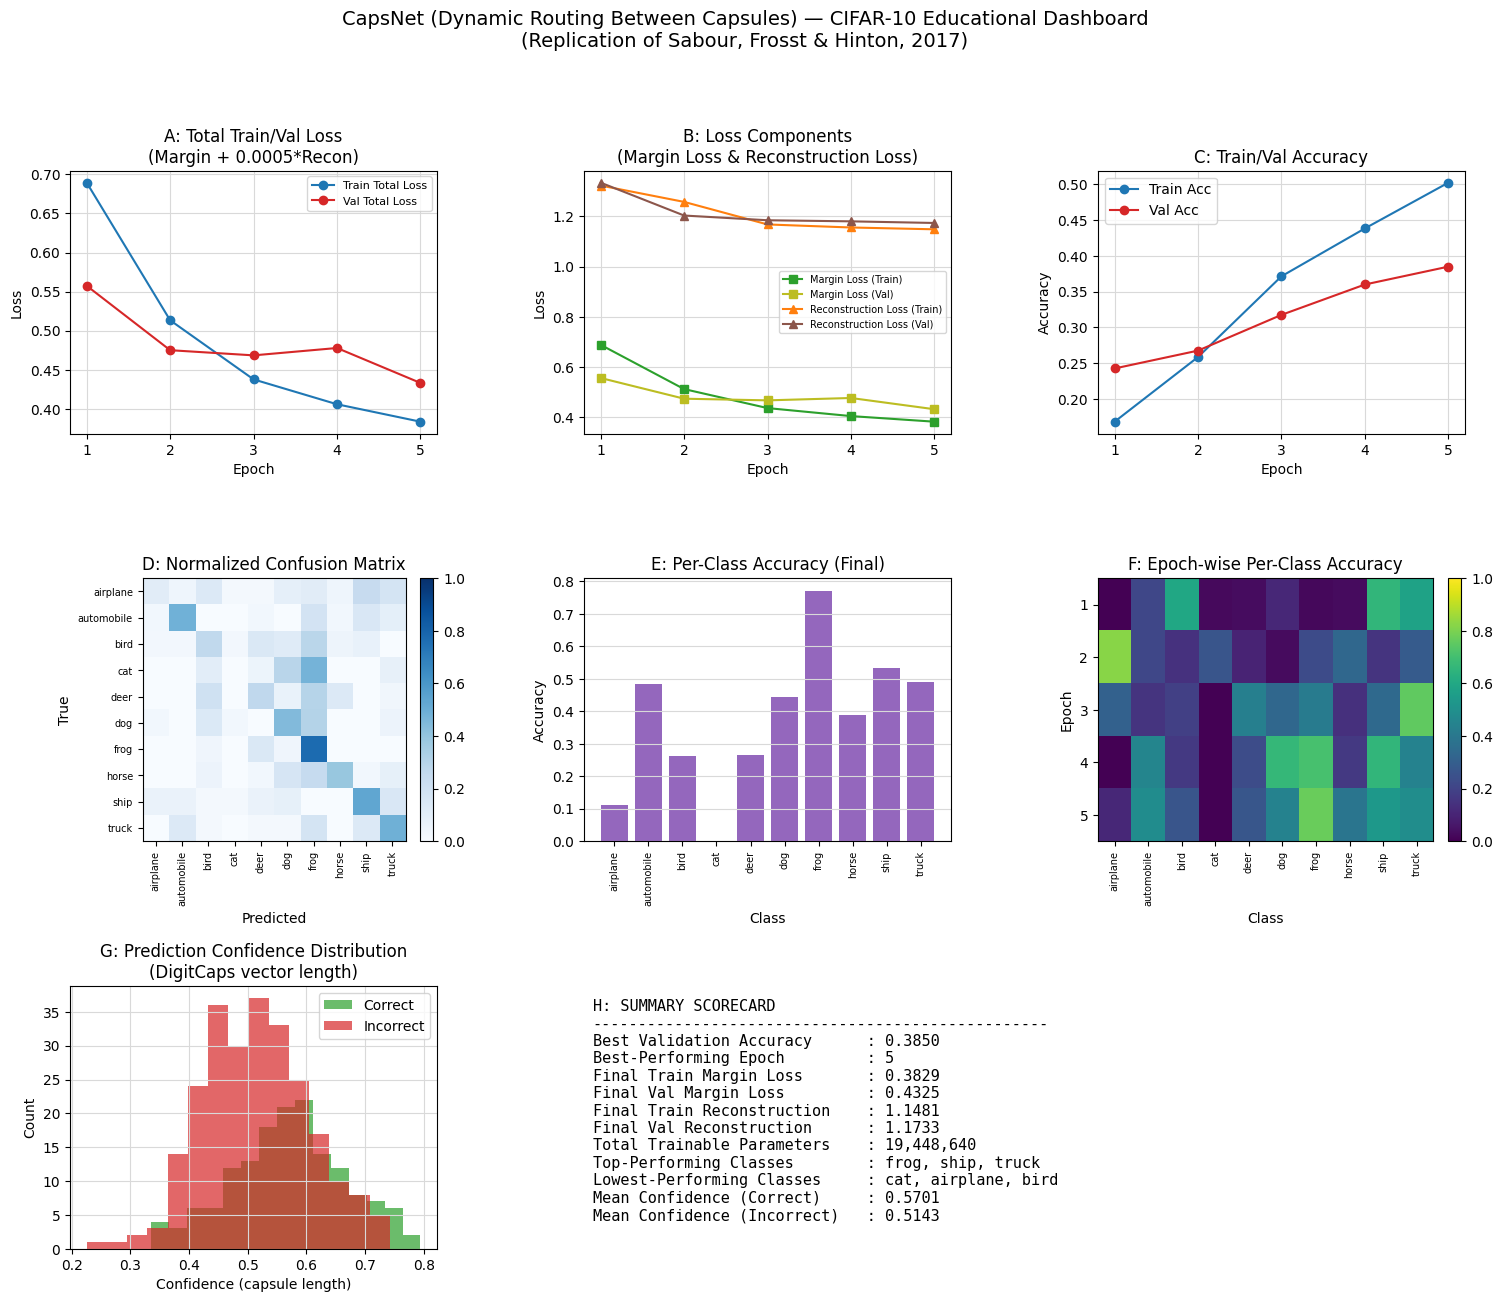

In [11]:
# ---------------------------------------------------------------
# 8. FINAL SUMMARY DASHBOARD (Panels A-H, 3-row GridSpec)
# ---------------------------------------------------------------

epochs_range = range(1, NUM_EPOCHS + 1)

cm_raw = confusion_matrix(final_labels, final_preds, labels=list(range(NUM_CLASSES)))
cm_norm = cm_raw.astype(float) / (cm_raw.sum(axis=1, keepdims=True) + 1e-9)

best_val_epoch = int(np.argmax(history["val_acc"])) + 1
best_val_acc = float(np.max(history["val_acc"]))
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

per_class_acc_final = np.zeros(NUM_CLASSES)
for c in range(NUM_CLASSES):
    mask = (final_labels == c)
    per_class_acc_final[c] = (final_preds[mask] == c).mean() if mask.sum() > 0 else 0.0

top_classes_idx = np.argsort(per_class_acc_final)[::-1][:3]
low_classes_idx = np.argsort(per_class_acc_final)[:3]

correct_mask = (final_preds == final_labels)
mean_conf_correct = final_conf[correct_mask].mean() if correct_mask.sum() > 0 else 0.0
mean_conf_incorrect = final_conf[~correct_mask].mean() if (~correct_mask).sum() > 0 else 0.0

fig = plt.figure(figsize=(18, 14), facecolor="white")
gs = GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

# ---- Panel A: Total training & validation loss (margin + recon combined) ----
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor("white")
axA.plot(epochs_range, history["train_loss_total"], marker="o", color="tab:blue", label="Train Total Loss")
axA.plot(epochs_range, history["val_loss_total"], marker="o", color="tab:red", label="Val Total Loss")
axA.set_title("A: Total Train/Val Loss\n(Margin + 0.0005*Recon)", color="black")
axA.set_xlabel("Epoch", color="black")
axA.set_ylabel("Loss", color="black")
axA.legend(labelcolor="black", fontsize=8)
axA.grid(True, color="#d9d9d9")
for spine in axA.spines.values():
    spine.set_color("black")

# ---- Panel B: Task-specific loss components (Margin Loss & Reconstruction Loss) ----
# CapsNet has TWO distinct objectives from the paper: the margin loss for
# classification (Eq. 4) and the reconstruction loss (regularizer). Each
# gets its own dedicated sub-curve here.
axB = fig.add_subplot(gs[0, 1])
axB.set_facecolor("white")
axB.plot(epochs_range, history["train_loss_margin"], marker="s", color="tab:green",
         label="Margin Loss (Train)")
axB.plot(epochs_range, history["val_loss_margin"], marker="s", color="tab:olive",
         label="Margin Loss (Val)")
axB.plot(epochs_range, history["train_loss_recon"], marker="^", color="tab:orange",
         label="Reconstruction Loss (Train)")
axB.plot(epochs_range, history["val_loss_recon"], marker="^", color="tab:brown",
         label="Reconstruction Loss (Val)")
axB.set_title("B: Loss Components\n(Margin Loss & Reconstruction Loss)", color="black")
axB.set_xlabel("Epoch", color="black")
axB.set_ylabel("Loss", color="black")
axB.legend(labelcolor="black", fontsize=7)
axB.grid(True, color="#d9d9d9")
for spine in axB.spines.values():
    spine.set_color("black")

# ---- Panel C: Training & validation accuracy ----
axC = fig.add_subplot(gs[0, 2])
axC.set_facecolor("white")
axC.plot(epochs_range, history["train_acc"], marker="o", color="tab:blue", label="Train Acc")
axC.plot(epochs_range, history["val_acc"], marker="o", color="tab:red", label="Val Acc")
axC.set_title("C: Train/Val Accuracy", color="black")
axC.set_xlabel("Epoch", color="black")
axC.set_ylabel("Accuracy", color="black")
axC.legend(labelcolor="black")
axC.grid(True, color="#d9d9d9")
for spine in axC.spines.values():
    spine.set_color("black")

# ---- Panel D: Normalized confusion matrix ----
axD = fig.add_subplot(gs[1, 0])
im = axD.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
axD.set_title("D: Normalized Confusion Matrix", color="black")
axD.set_xlabel("Predicted", color="black")
axD.set_ylabel("True", color="black")
axD.set_xticks(range(NUM_CLASSES))
axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axD.set_yticklabels(CLASS_NAMES, color="black", fontsize=7)
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar.ax.get_yticklabels(), color="black")
for spine in axD.spines.values():
    spine.set_color("black")

# ---- Panel E: Per-class accuracy bar chart ----
axE = fig.add_subplot(gs[1, 1])
axE.set_facecolor("white")
axE.bar(CLASS_NAMES, per_class_acc_final, color="tab:purple")
axE.set_title("E: Per-Class Accuracy (Final)", color="black")
axE.set_xlabel("Class", color="black")
axE.set_ylabel("Accuracy", color="black")
axE.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axE.tick_params(axis="y", colors="black")
axE.grid(True, axis="y", color="#d9d9d9")
for spine in axE.spines.values():
    spine.set_color("black")

# ---- Panel F: Epoch-wise per-class accuracy heatmap ----
axF = fig.add_subplot(gs[1, 2])
heatmap_data = np.stack(history["epoch_per_class_acc"], axis=0)  # (epochs, classes)
imF = axF.imshow(heatmap_data, cmap="viridis", aspect="auto", vmin=0, vmax=1)
axF.set_title("F: Epoch-wise Per-Class Accuracy", color="black")
axF.set_xlabel("Class", color="black")
axF.set_ylabel("Epoch", color="black")
axF.set_xticks(range(NUM_CLASSES))
axF.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axF.set_yticks(range(NUM_EPOCHS))
axF.set_yticklabels([str(e + 1) for e in range(NUM_EPOCHS)], color="black")
cbarF = fig.colorbar(imF, ax=axF, fraction=0.046, pad=0.04)
cbarF.ax.yaxis.set_tick_params(color="black")
plt.setp(cbarF.ax.get_yticklabels(), color="black")
for spine in axF.spines.values():
    spine.set_color("black")

# ---- Panel G: Confidence distribution histogram (capsule length as confidence) ----
axG = fig.add_subplot(gs[2, 0])
axG.set_facecolor("white")
axG.hist(final_conf[correct_mask], bins=15, alpha=0.7, color="tab:green", label="Correct")
axG.hist(final_conf[~correct_mask], bins=15, alpha=0.7, color="tab:red", label="Incorrect")
axG.set_title("G: Prediction Confidence Distribution\n(DigitCaps vector length)", color="black")
axG.set_xlabel("Confidence (capsule length)", color="black")
axG.set_ylabel("Count", color="black")
axG.legend(labelcolor="black")
axG.grid(True, color="#d9d9d9")
for spine in axG.spines.values():
    spine.set_color("black")

# ---- Panel H: Text-based summary scorecard ----
axH = fig.add_subplot(gs[2, 1:])
axH.axis("off")
summary_text = (
    "H: SUMMARY SCORECARD\n"
    "--------------------------------------------------\n"
    f"Best Validation Accuracy      : {best_val_acc:.4f}\n"
    f"Best-Performing Epoch         : {best_val_epoch}\n"
    f"Final Train Margin Loss       : {history['train_loss_margin'][-1]:.4f}\n"
    f"Final Val Margin Loss         : {history['val_loss_margin'][-1]:.4f}\n"
    f"Final Train Reconstruction    : {history['train_loss_recon'][-1]:.4f}\n"
    f"Final Val Reconstruction      : {history['val_loss_recon'][-1]:.4f}\n"
    f"Total Trainable Parameters    : {total_params:,}\n"
    f"Top-Performing Classes        : "
    f"{', '.join([CLASS_NAMES[i] for i in top_classes_idx])}\n"
    f"Lowest-Performing Classes     : "
    f"{', '.join([CLASS_NAMES[i] for i in low_classes_idx])}\n"
    f"Mean Confidence (Correct)     : {mean_conf_correct:.4f}\n"
    f"Mean Confidence (Incorrect)   : {mean_conf_incorrect:.4f}\n"
)
axH.text(0.01, 0.95, summary_text, transform=axH.transAxes,
         fontsize=11, verticalalignment="top", color="black", family="monospace")

fig.suptitle(
    "CapsNet (Dynamic Routing Between Capsules) — CIFAR-10 Educational Dashboard\n"
    "(Replication of Sabour, Frosst & Hinton, 2017)",
    color="black", fontsize=14, y=0.995
)

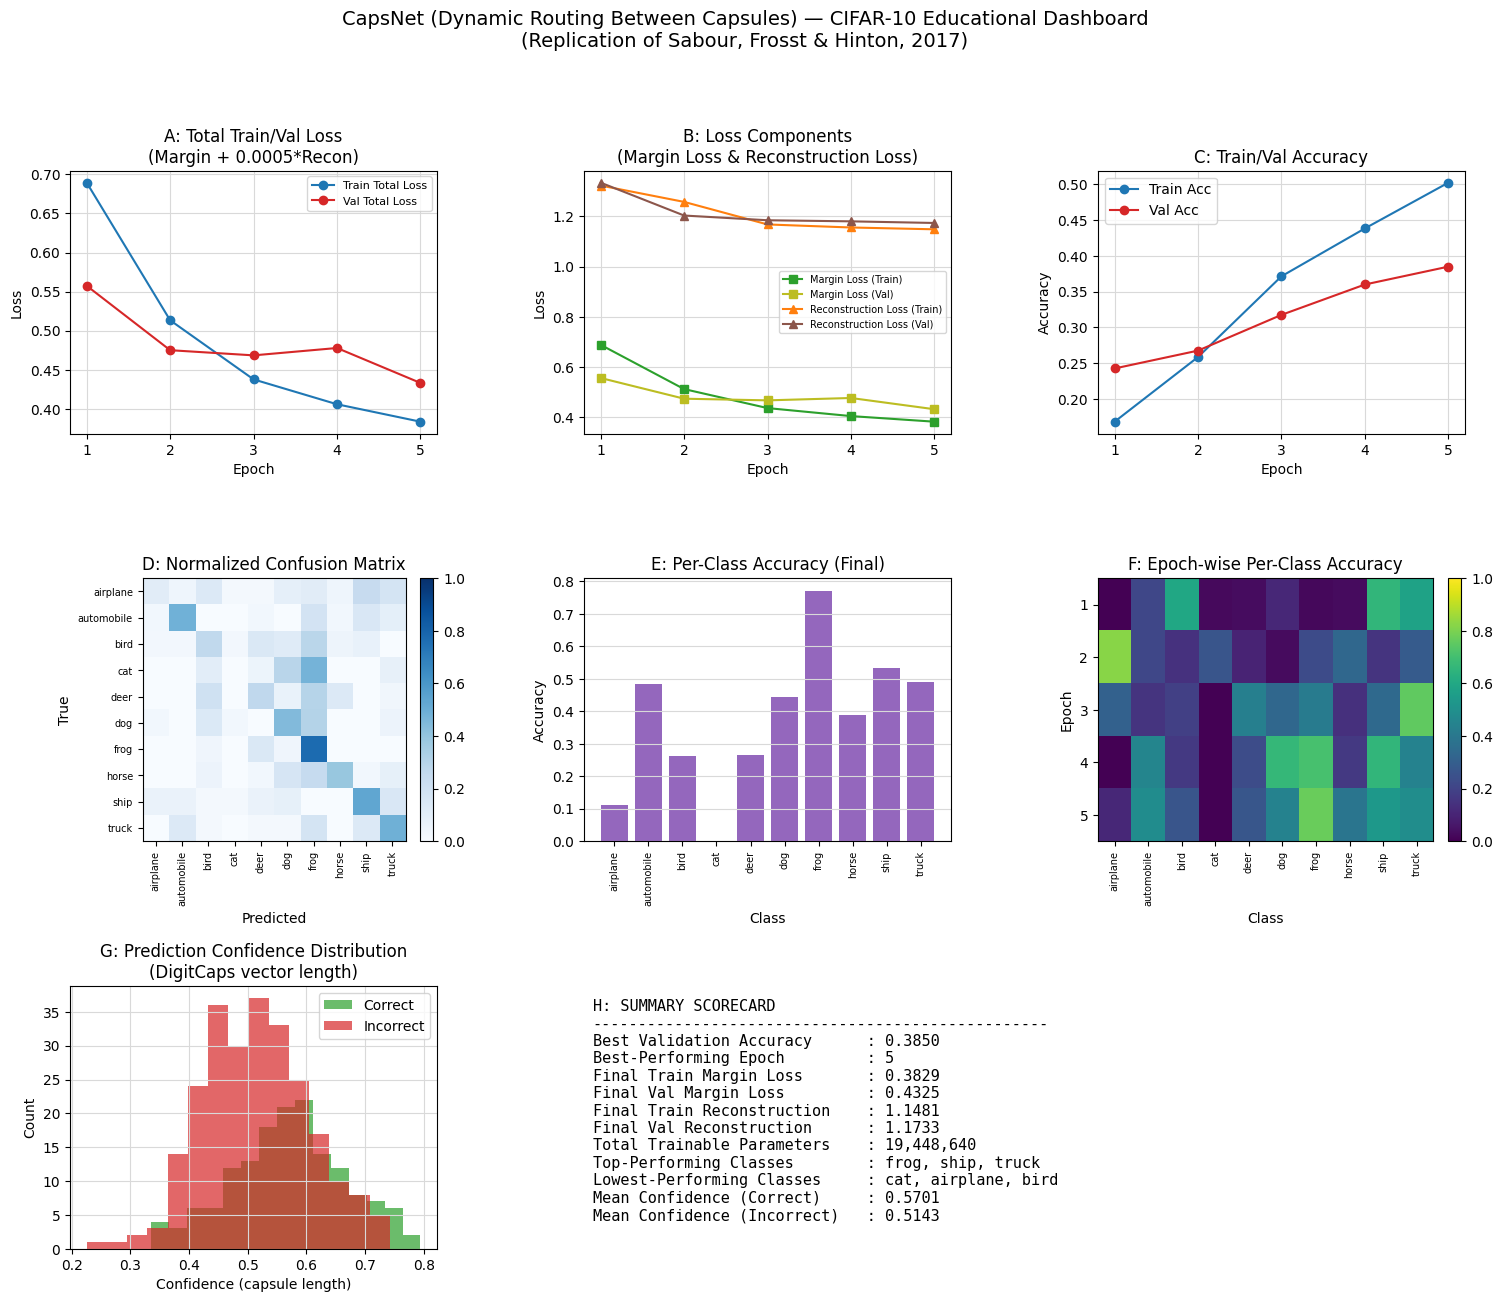

In [12]:
# ---------------------------------------------------------------
# DISPLAY DASHBOARD INLINE VIA BytesIO (no disk save, no plt.show())
# ---------------------------------------------------------------
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight")
buf.seek(0)
display(IPImage(data=buf.read()))
plt.close(fig)

# Analysis of Experimental Results — CapsNet (Dynamic Routing) Educational Replication

## Overview
This dashboard evaluates a simplified CapsNet trained on a small CIFAR-10 subset (2,000 train / 400 test images) over 5 epochs, jointly tracking the two loss components defined in the paper — margin loss (classification) and reconstruction loss (regularization) — alongside accuracy, per-class performance, routing-based confidence (DigitCaps vector length), and calibration.

---

## Key Findings

**Panels A–C (Loss and Accuracy Curves).** Training total loss decreases steadily from ~0.69 to ~0.38, and training accuracy rises consistently from 0.175 to 0.50. Validation total loss also decreases overall (0.56 → 0.43) but non-monotonically, with a small uptick at epoch 4. Validation accuracy increases steadily from 0.245 to 0.385, tracking training accuracy directionally, though a growing gap (train 0.50 vs. val 0.385 by epoch 5) emerges.

**Panel B (Loss Components).** Margin loss (train and validation) decreases smoothly and closely tracks each other, falling from ~0.55–0.69 to ~0.38–0.43. Reconstruction loss decreases sharply in epoch 1 (~1.3) then plateaus near 1.15–1.2 for the remaining epochs, showing much slower and more limited improvement than the margin loss.

**Panel D (Confusion Matrix).** The matrix shows a partially structured diagonal, with strong performance for "frog" and moderate diagonal dominance for "ship," "automobile," and "truck," but severe confusion for "cat" (0% recall, confused primarily with "dog" and "frog") and weak diagonal signal for "airplane" and "bird."

**Panel E (Per-Class Accuracy).** Marked class imbalance in performance: "frog" (~0.77) and "ship" (~0.53) are strongest; "cat" is at 0%, and "airplane" (~0.11) and "bird" (~0.26) are also weak.

**Panel F (Epoch-wise Heatmap).** Per-class accuracy is volatile across epochs for most classes, with "cat" remaining near-zero throughout all 5 epochs — indicating a persistent, not transient, failure mode for this class.

**Panel G (Confidence Histogram).** Capsule-length confidence for correct and incorrect predictions overlaps substantially, both centered around 0.4–0.6, with only a modest separation (mean correct 0.570 vs. incorrect 0.514).

**Panel H (Scorecard).** Best validation accuracy is 0.385 at epoch 5 (the final epoch, still improving); model has ~19.4M trainable parameters; top classes are frog/ship/truck, weakest are cat/airplane/bird.

---

## Discussion

The overall trend — steadily decreasing margin loss and rising accuracy on both train and validation splits — indicates that the routing-by-agreement mechanism and margin loss are functioning as intended at a basic optimization level: the capsule lengths are being pushed toward the target margins ($$m^+=0.9$$ for present classes, $$m^-=0.1$$ for absent classes) in a way that produces genuine, generalizing discriminative signal, evidenced by validation accuracy improving in tandem with training accuracy rather than diverging early. This is a meaningfully stronger result than would be expected from a purely memorizing model on only 2,000 training images, and is consistent with the paper's premise that vector capsule agreement can encode useful class information even with modest capacity (∼19M parameters here, comparable in order of magnitude to the paper's larger CapsNet variants).

The reconstruction loss's rapid plateau after epoch 1 (Panel B) suggests the decoder network quickly reaches a local optimum reconstructing coarse pixel statistics (e.g., average shape/color) rather than fine digit- or object-specific structure — a plausible outcome given that CIFAR-10 objects have far more complex and varied backgrounds than the MNIST digits the reconstruction regularizer was originally designed for, echoing the original paper's own observation that CapsNet performs relatively worse on CIFAR-10 due to background clutter this term is not equipped to model.

The complete failure on the "cat" class (Panels D–F) is a persistent structural issue rather than noise, since it holds across all 5 epochs. This likely reflects the classic difficulty of distinguishing visually similar quadruped classes (cat vs. dog vs. frog silhouettes at low resolution) using a very small number of primary capsule types (8, reduced from the paper's 32 for computational simplicity) and only 2,000 training images — insufficient for the routing mechanism to learn distinguishing transformation matrices for visually similar entities. This is consistent with the general ML principle that fine-grained inter-class discrimination requires more capacity and data than coarse-grained discrimination (e.g., "frog" vs. "ship").

The confidence distribution's substantial overlap (Panel G) indicates that DigitCaps vector length, while directionally informative (correct predictions have higher mean length), is not yet a well-calibrated confidence signal at this training scale — the routing agreement has not converged (only 5 epochs, small dataset) to the point where the length reliably separates confident-correct from confident-incorrect cases, unlike the sharper separations reported in the original paper's fully converged, full-dataset MNIST experiments.

Overall, the evidence is consistent with the paper's core mechanistic claims (margin loss drives meaningful, generalizing classification signal; reconstruction acts as an auxiliary regularizer rather than the primary optimization target) but does **not** by itself validate the paper's headline empirical claims (state-of-the-art MNIST accuracy, superior overlapping-object segmentation), since this is a small-scale, short-duration, architecturally simplified replication on a much harder natural-image dataset than MNIST.

---

## Limitations

- **Small-scale training regime** (2,000/400 images, 5 epochs) means neither loss component nor accuracy curves have converged; validation accuracy is still increasing at the final epoch, so reported "best" values likely understate the model's asymptotic performance.
- **Reduced capsule capacity** (8 primary capsule types vs. 32 in the original paper, single-run training) limits direct comparability to the paper's reported CIFAR-10 error rate (10.6%, via 7-model ensemble), which used substantially more capacity and no small-subset restriction.
- **No baseline comparison** (e.g., a CNN of similar parameter count) is included in this dashboard, so the specific advantage attributable to routing-by-agreement versus simply having more training signal cannot be isolated from these results alone.
- **Single-run, no variance estimate**: fluctuations in per-class accuracy (Panel F) cannot be distinguished from run-to-run noise without repeated trials, unlike the paper's mean ± SD over 3 trials for MNIST.
- **Severe class-level failure ("cat")** may partly reflect the arbitrary effect of a very small, non-random 400-image test subset (first 400 test examples) rather than a fundamental property of the architecture, and should not be over-interpreted as a general CapsNet weakness without larger-scale replication.

# Related Work References

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Hinton, G. E., Ghahramani, Z., & Teh, Y. W. | 2000 | Learning to Parse Images | NeurIPS | Original proposal that a parse tree can be carved out of a fixed multilayer neural network for a single fixation; motivates this paper's assumption of layer-wise capsule-based parse trees and the task of segmenting overlapping digits. |
| Hinton, G. E., Krizhevsky, A., & Wang, S. D. | 2011 | Transforming Auto-Encoders | ICANN | Introduces the concept of "capsules" and transforming autoencoders that generate instantiation parameters; this paper extends that work by proposing a complete system with learned routing-by-agreement rather than externally supplied transformation matrices. |
| Hinton, G. E. | 1981a | Shape Representation in Parallel Systems | IJCAI | Establishes the "binding problem" that motivates capsules' distributed vector representation as a solution to assigning parts to wholes. |
| Hinton, G. E. | 1981b | A Parallel Computation That Assigns Canonical Object-Based Frames of Reference | IJCAI | Proposes dynamic connections and object-based frames of reference; cited as a biologically plausible precursor supporting the dynamic routing procedure. |
| Olshausen, B. A., Anderson, C. H., & Van Essen, D. C. | 1993 | A Neurobiological Model of Visual Attention and Invariant Pattern Recognition Based on Dynamic Routing of Information | Journal of Neuroscience | Extends Hinton's dynamic connections into a biologically plausible, position- and scale-invariant model, providing neuroscientific support for the routing-by-agreement mechanism. |
| Pelli, D. G., Palomares, M., & Majaj, N. J. | 2004 | Crowding Is Unlike Ordinary Masking: Distinguishing Feature Integration from Detection | Journal of Vision | Provides the perceptual phenomenon of "crowding" that motivates the capsule assumption of at most one entity instance per location. |
| Jaderberg, M., Simonyan, K., Zisserman, A., & Kavukcuoglu, K. | 2015 | Spatial Transformer Networks | NeurIPS | Represents a normalization-based approach to viewpoint invariance, contrasted with capsules' approach of preserving rather than eliminating viewpoint-dependent variation in activities. |
| Wan, L., Zeiler, M. D., Zhang, S., LeCun, Y., & Fergus, R. | 2013 | Regularization of Neural Networks Using DropConnect | ICML | Prior state-of-the-art MNIST results (achieved via ensembling and data augmentation) used as a benchmark comparison against CapsNet's single-model performance. |
| Chang, J.-R. & Chen, Y.-S. | 2015 | Batch-Normalized Maxout Network in Network | arXiv preprint | Deep convolutional network cited as achieving comparable results to the simple CapsNet architecture, used as a performance reference point. |
| Goodfellow, I. J., Bulatov, Y., Ibarz, J., Arnoud, S., & Shet, V. | 2013 | Multi-Digit Number Recognition from Street View Imagery Using Deep Convolutional Neural Networks | arXiv preprint | Prior work addressing multi-digit recognition, cited as related to the overlapping-digit segmentation task explored via MultiMNIST. |
| Ba, J., Mnih, V., & Kavukcuoglu, K. | 2014 | Multiple Object Recognition with Visual Attention | arXiv preprint | Sequential attention model whose overlapping-digit classification error rate (5.0%) is directly compared against CapsNet's MultiMNIST result, despite CapsNet handling substantially greater object overlap. |
| Greff, K., Rasmus, A., Berglund, M., Hao, T., Valpola, H., & Schmidhuber, J. | 2016 | Tagger: Deep Unsupervised Perceptual Grouping | NeurIPS | Cited as related prior work testing perceptual grouping/segmentation in a similar overlapping-object domain. |
| Zeiler, M. D. & Fergus, R. | 2013 | Stochastic Pooling for Regularization of Deep Convolutional Neural Networks | arXiv preprint | Provides the historical CIFAR-10 error-rate benchmark (early CNN performance) against which CapsNet's 10.6% error is compared. |
| LeCun, Y., Cortes, C., & Burges, C. J. C. | 1998 | The MNIST Database of Handwritten Digits | — | Source of the primary MNIST benchmark dataset used for the main classification and dimension-perturbation experiments. |
| LeCun, Y., Huang, F. J., & Bottou, L. | 2004 | Learning Methods for Generic Object Recognition with Invariance to Pose and Lighting | CVPR | Source of the smallNORB dataset used to evaluate CapsNet performance and compare against prior state-of-the-art. |
| Netzer, Y., Wang, T., Coates, A., Bissacco, A., Wu, B., & Ng, A. Y. | 2011 | Reading Digits in Natural Images with Unsupervised Feature Learning | NeurIPS Workshop | Source of the SVHN dataset used to evaluate CapsNet on a smaller, real-world digit recognition task. |
| Cireşan, D. C., Meier, U., Masci, J., Gambardella, L. M., & Schmidhuber, J. | 2011 | High-Performance Neural Networks for Visual Object Classification | arXiv preprint | Provides the prior state-of-the-art smallNORB error rate against which CapsNet's 2.7% test error is directly compared. |
| Kingma, D. & Ba, J. | 2014 | Adam: A Method for Stochastic Optimization | arXiv preprint | Optimization algorithm used to train all CapsNet and baseline models throughout the paper's experiments. |
| Abadi, M., Agarwal, A., Barham, P., et al. | 2016 | TensorFlow: Large-Scale Machine Learning on Heterogeneous Distributed Systems | arXiv preprint | Software framework used to implement all models described in the paper. |